实验：对比 fit_uni 和 fit_unilasso 的训练/测试误差
数据设置: n_samples=500, n_features=50
稀疏度: 3 个非零系数 (k-sparse)
信号强度: 3.0
数据分割: 训练集=70%, 测试集=30%
正则化路径长度: 100

[1/4] 生成 k-稀疏模拟数据...
  真实非零系数位置: [ 0  2 27]
  真实非零系数值: [-1.39586868 -0.96158114 -2.89169962]

[2/4] 分割数据集 (训练集: 70%, 测试集: 30%)...
  训练集大小: 350
  测试集大小: 150

[3/4] 训练 fit_unilasso 模型...
Training unilasso model...


 44%|          | 0/100 [00:00:00<?, ?it/s]████      | 44/100 [00:00:00<00:00:00, 16205.69it/s] [dev:90.0%]


Number of Selected Features: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 1 1 1 1 1 1 1
 1 1 1 1 1 1 0]
Regularization path (rounded to 3 decimal places): [0.129 0.141 0.155 0.17  0.187 0.205 0.225 0.247 0.271 0.297 0.326 0.358
 0.393 0.431 0.473 0.519 0.57  0.626 0.687 0.754 0.827 0.908 0.996 1.093
 1.2   1.317 1.445 1.586 1.741 1.911 2.097 2.302 2.526 2.772 3.043 3.339
 3.665 4.022 4.414 4.845 5.317 5.835 6.404 7.029]

[4/4] 训练 fit_uni 模型...
Training uni model...


Number of Selected Features: [ 2  2  2  2  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  4
  5  5  5  6  6  8 10 10 12 12 12 12 13 13 14 14 14 15 15 16 16 16 16 16
 16 16 17 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18
 18 18 18 18]
Regularization path (rounded to 3 decimal places): [2.802e+00 2.553e+00 2.326e+00 2.120e+00 1.931e+00 1.760e+00 1.603e+00
 1.461e+00 1.331e+00 1.213e+00 1.105e+00 1.007e+00 9.180e-01 8.360e-01
 7.620e-01 6.940e-01 6.320e-01 5.760e-01 5.250e-01 4.780e-01 4.360e-01
 3.970e-01 3.620e-01 3.300e-01 3.000e-01 2.740e-01 2.490e-01 2.270e-01
 2.070e-01 1.890e-01 1.720e-01 1.570e-01 1.430e-01 1.300e-01 1.190e-01
 1.080e-01 9.800e-02 9.000e-02 8.200e-02 7.400e-02 6.800e-02 6.200e-02
 5.600e-02 5.100e-02 4.700e-02 4.300e-02 3.900e-02 3.500e-02 3.200e-02
 2.900e-02 2.700e-02 2.400e-02 2.200e-02 2.000e-02 1.800e-02 1.700e-02
 1.500e-02 1.400e-02 1.300e-02 1.200e-02 1.100

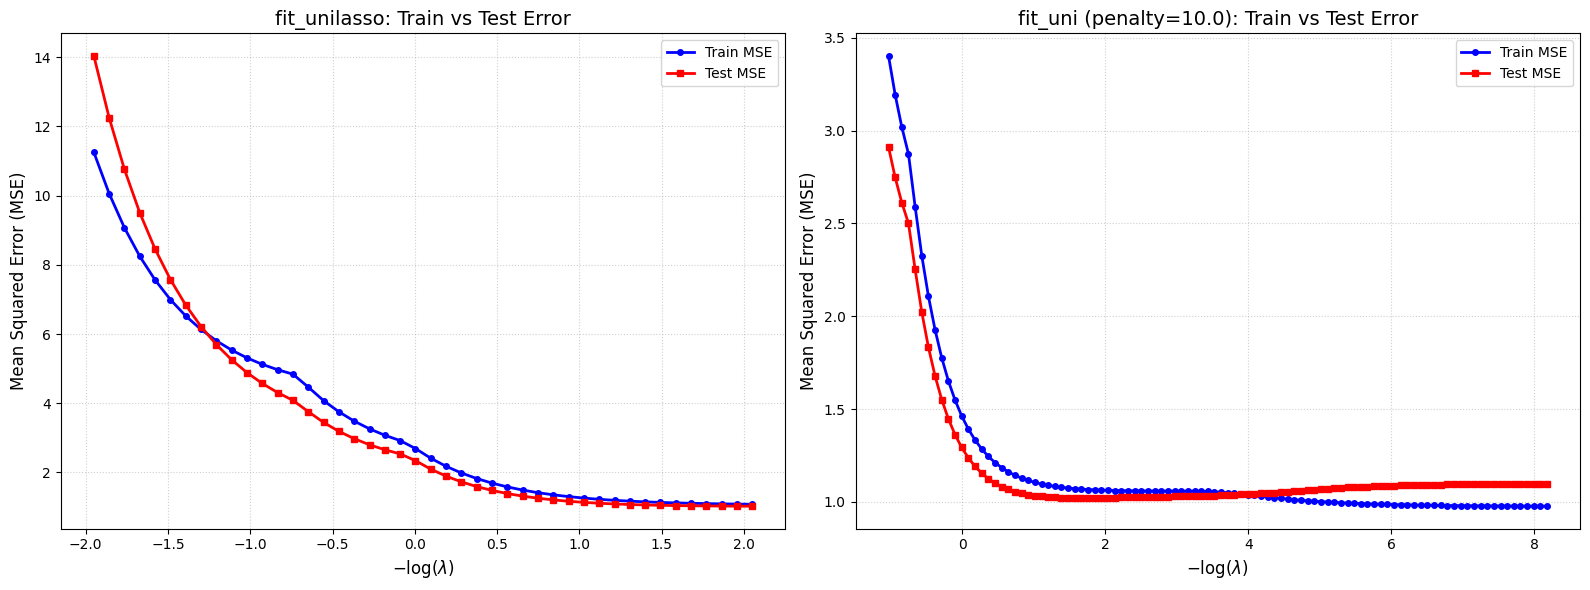


实验结果摘要
真实稀疏度: 3 / 50 (6.0%)

fit_unilasso:
  最佳 lambda: 0.128676
  最佳 -log(lambda): 2.0505
  最佳测试 MSE: 1.022980
  选中特征数: 3
  真实特征召回率: 3/3

fit_uni (negative_penalty=10.0):
  最佳 lambda: 0.188692
  最佳 -log(lambda): 1.6676
  最佳测试 MSE: 1.021030
  选中特征数: 3
  真实特征召回率: 3/3


In [1]:
from experiments import run_comparison_experiment

# 高稀疏场景：50个特征中只有3个有效
unilasso_res, uni_res = run_comparison_experiment(
    n_samples=500,
    n_features=50,      # 50个特征
    sparsity=3,         # 只有3个真正有非零系数
    signal_strength=3.0, # 信号较强
    test_size=0.3,      # 三七分
    negative_penalty=10.0,
    save_path="experiment1_comparison.png"
)

实验2：fit_uni 的 negative_penalty 调参实验

[1/2] 生成 k-稀疏模拟数据...
  样本数: 300, 特征数: 15
  稀疏度: 4/15
  真实非零系数位置: [ 0  3  4 14]
  数据分割: 训练集=210, 测试集=90

[2/2] 开始调参实验...
实验2：fit_uni 的 negative_penalty 调参
惩罚系数范围: [0.00, 100.00]
测试点数: 21
每个模型的正则化路径长度: 30


Tuning negative_penalty:   0%|          | 0/21 [00:00<?, ?it/s]

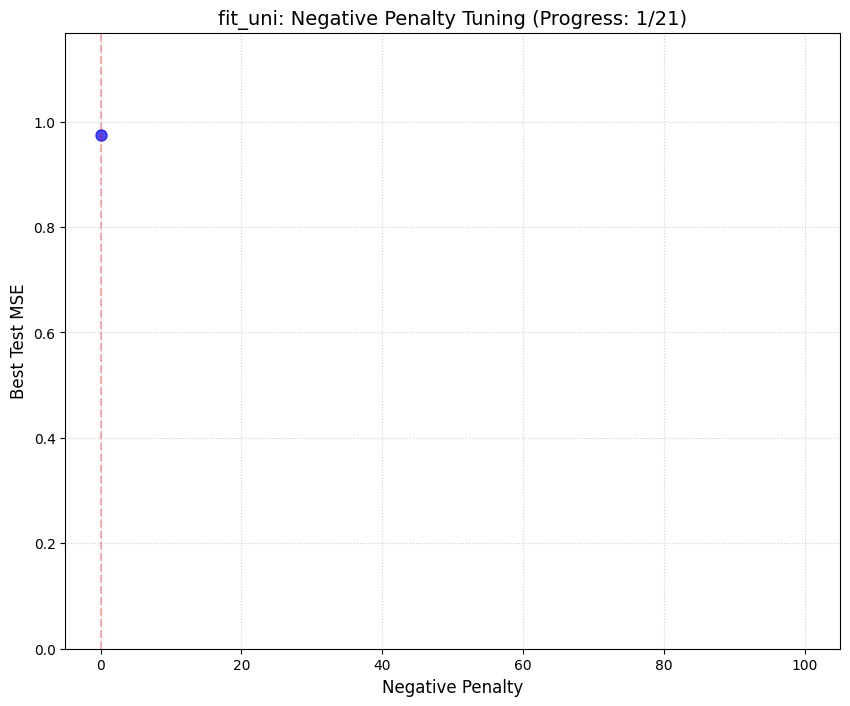

Tuning negative_penalty: 100%|██████████| 21/21 [02:11<00:00,  6.26s/it]



最终图片已保存至: experiment2_penalty_tuning.png


<Figure size 640x480 with 0 Axes>


实验2结果摘要
最佳惩罚系数: 0.0000
对应最佳测试 MSE: 0.973956
对应训练 MSE: 0.906552
对应最佳 lambda: 0.000229
选中特征数: 15

最差测试 MSE: 1.028953 (penalty=5.00)
MSE 标准差: 0.011712


In [ ]:
# from IPython.display import clear_output, display

# # 在循环中：
# clear_output(wait=True)
# display(fig)
from experiments import run_experiment2

# # 运行完整的调参实验
# results = run_experiment2(
#     n_samples=300,
#     n_features=15,
#     sparsity=4,
#     penalty_range=(0, 100),  # 从0到100
#     n_points=21,             # 测试21个点
#     n_lmdas=30,              # 每个模型30个lambda
#     dynamic_plot=True,       # 开启动态画图
#     save_path="experiment2_penalty_tuning.png"
# )

# # 或者使用底层函数
# from experiments import experiment_negative_penalty_tuning

# results = experiment_negative_penalty_tuning(
#     X_train=X_train,
#     y_train=y_train,
#     X_test=X_test,
#     y_test=y_test,
#     penalty_values=[0, 1, 5, 10, 20, 50, 100],  # 自定义测试点
#     dynamic_plot=True
# )

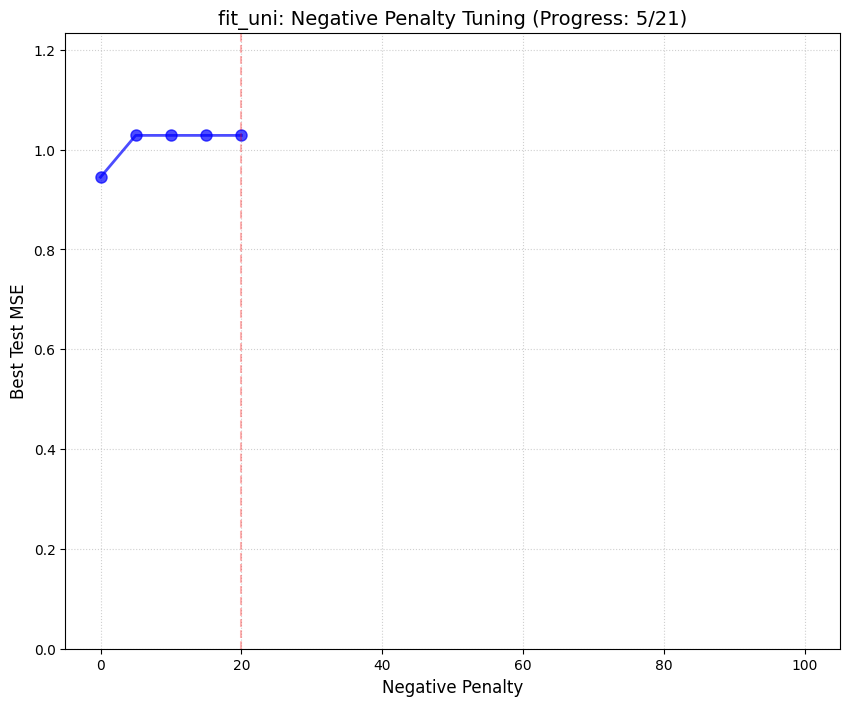

In [ ]:
from experiments import run_experiment2

# 在 Jupyter 中运行会自动检测并使用 notebook 版本的 tqdm 和动态画图
results = run_experiment2(
    n_samples=300,
    n_features=15,
    sparsity=4,
    penalty_range=(0, 100),
    n_points=21,
    n_lmdas=100,
    dynamic_plot=True,  # 在 Jupyter 中会使用 clear_output + display
    save_path="experiment2_penalty_tuning.png"
)